# Activity 04: Hare and Lynx Population Interactions
-------
## Overview

In this lesson you will simulate the interaction of the Snow Hares and Lynx populations using a __for__ loop. 

The exercises in the lesson will show how to: 
1. Simulate the two populations one year into the future.
2. Simulate the two populations one year into the future using half-year timesteps.
3. Code the processes as a _recurrent_ process to predict the populations in general.
4. Coding a __for loop__ and two __arrays__ to predict the populations in the future.
5. Plotting the population simulations as a function of time.
6. Reflect on what the plot tells about the interaction of the snow hares and lynxes.


In [1]:
## Library

# Import NumPy for numerical operations and array handling
import numpy as np

# Import Matplotlib's pyplot module for plotting
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle


# Enable inline plotting in Jupyter notebooks so plots appear directly below the code cells
%matplotlib inline

# Import the warnings module to manage warning messages (e.g., suppress or customize them)
import warnings



## Predicting Hare–Lynx Population Interaction One Year Ahead

### Coding Exercise 6.4a: Predicting the Future Hare Population

In Lesson 3, we modelled the hare population, `H`, without predators by assuming that the population increases due to births. This was done by adding the current population to the number of new hares born in one year:

$$
H = H + r_{\text{Birth}} \times H
$$

To model the interaction between snow hares and their predators, lynx (`L`), we now include the effect of predation. Lynx reduce the hare population by catching and eating them, which we model using a multiplication and subtraction term:

$$H = H + r_{\text{Birth}} \times H - r_{\text{Eat}} \times H \times L $$

Suppose the hare population in 1895 is `H = 85` and the lynx population is `L = 51`. The birth rate is `r_Birth = 0.9`, and the eating rate is `r_Eat = 0.024`.

Calculate the hare population after one year using:

$$
85 + (0.9 \times 85) - (0.024 \times 85 \times 51) = 57.46
$$


In [ ]:
## Solution Coding Exercise 6.4a: Predicting the Future Hare Population

85 + (0.9*85)-0.024*85*51

57.459999999999994

### Coding Exercise 6.4b: Predicting the Future Lynx Population

In Lesson 2, we modelled the lynx population, `L`, without their prey (hares, `H`) by assuming that the population decreases due to deaths. This was done by subtracting the number of lynx that die in one year from the current population:

$$ L = L - r_{\text{Death}} \times L.$$


To model the interaction between snow lynx and hares, we now include the effect of food availability. When lynx catch and eat hares, this provides energy that increases the lynx population. We model this using a multiplication and addition term:

$$L = L - r_{\text{Death}} \times L + r_{\text{Food}} \times L \times H. $$

Suppose the lynx population in 1895 is `L = 51` and the hare population is `H = 85`. The death rate is `r_Death = 0.25`, and the food rate is `r_Food = 0.005`.

Calculate the lynx population after one year using:

$$ 51 - (0.25 \times 51) + (0.005 \times 85 \times 51) = 59.93. $$


In [ ]:
### Solution Coding Exercise 4.1b: Predicting the Future Lynx Population
51 - (0.25*51)+0.005*85*51

59.925

## Predicting One Year in the Future using half year steps


### Coding Exercise 4.2: Predicting Three Years
Given the initial Hare population is 85 implement the formula three times to get the population in 1898.

## Predicting One Year in the Future using half year steps

$$ H=H+r\_Birth \times H-r\_Eat\times H\times L,$$
$$ L= L + (-r\_{Death} \times L + r_{Food} \times L \times H). $$


$$ \textcolor{red}{H}= H + timestep\times(r_{Birth} \times H - r_{Eat} \times L \times H), $$
$$\textcolor{red}{L}= L + timestep\times(-r_{Death} \times L + r_{Food} \times L \times H). $$

### Coding Exercise 6.2: Predicting One Year with half-year steps

Given the initial Lynx population is 51 implement the formula three times to get the population in 1898.

## Time Step 
In the previous lesson we have introduced a time step `timestep`, to predict the Hare and Lynx populations using recurrent equations: 
$$\textcolor{red}{H}= H+ timestep( + r_{Birth}  H), $$
$$\textcolor{red}{L}= L +timestep(- r_{Death}  L). $$

Here we extend the recurrent equations to include the interactions:

$$\textcolor{red}{H}= H+ timestep( + r_{Birth}  H-r_{Eat}HL), $$
$$\textcolor{red}{L}= L +timestep(- r_{Death}  L+r_{Food}HL). $$

### Calculations
To estimate the populations after half a year,`timestep=0.5`, suppose:
* Hare population, H=85, birth rate, $r_{Birth}=0.2$, and $r_{Eat}=0.024,$
* Lynx population, L=51, death rate, $r_{Death}=0.1$, and $r_{Food}=0.005.$

To simulate the population in 1895.5 use the formula
$$ H + 0.5*(0.9 * H-0.024*(H*L)  ), $$
$$ L + 0.5*(-0.25 * L+0.005*(L*H) ). $$


In [ ]:
L=51
H=85

### Solution Calculation 4.2: 


L=L+0.5*(-0.25*L+0.005*H*L) # 1895.5
H=H+0.5*(0.9*L-0.024*H*L)  # 1895.5
print('Simulated Population in 1895.5, Hare: ',H,' Lynx:', L)

L=L+0.5*(-0.25*L+0.005*H*L)
H=H+0.5*(0.9*L-0.024*H*L)  # 1896

print('Simulated Population in 1896, Hare: ',H,' Lynx:', L)

Simulated Population in 1895.5, Hare:  53.386375  Lynx: 55.4625
Simulated Population in 1896, Hare:  42.7236862640969  Lynx: 55.93204205859375


Simulated Population in 1895.5, Hare:  53.386375  Lynx: 55.4625

Simulated Population in 1896, Hare:  42.7236862640969  Lynx: 55.93204205859375

## Predicting Many Years in the Future

In the previous lesson we saw that the smaller the timestep the more accuarate the simulation so we will set the `timestep=0.01` which gives 4000 steps.

In [5]:
timestep=0.01
time=np.arange(1895,1935+timestep/2,timestep)

N=len(time) # Number of Steps
H=np.zeros(N) # Numerical Solution Hares
H[0]=85# Intial Hare population
L=np.zeros(N) # Numerical Solution Lynxes
L[0]=51# Initial Lynx population

## Recurrent Equations 

The hare and lynx populations can be modeled using a __recurrent equation__, which references its previous value.

This can be code using two arrays and a __for__ loop:

$$ H[i+1] = H[i]+ timestep*\big(r\_{growth}*H[i]-r\_{eat}*H[i]*L[i] \big), $$

$$ L[i+1] = L[i]+ timestep*\big(-r\_{death}*H[i]+r\_{food}*H[i]*L[i] \big), $$

where $timestep$ is the timestep and  $H[i]$ and $L[i]$ is the simulation  of the hare $H(t_i)$ and Lynx $L(t_i)$ at time $t_i$, for $i=0,...,N$.

### Coding Exercise 4.3: Recurrent Equations with a __for__ Loop

Given:

- Initial hare population in 1895: $H[0]=85$
- Initial lynx population in 1895: $L[0]=51$
- Birth rate: $r_{\text{Birth}} = 0.9$
- Death rate: $r_{\text{Death}} = 0.25$
- Food rate: $r_{\text{Food}} = 0.024$
- Eat rate: $r_{\text{Eat}} = 0.005$

Write code to implement the recurrent equation to simulate the hare and lynx populations using a for loop.




In [6]:
r_birth=0.9
r_eat=0.024
r_death=0.25 
r_food=0.005 

for i in range (0,N-1):
    ### Solution Coding Exercise 6.3: Recurrent Equations
    # Update the hare population for the next year based on the current population
     
    H[i+1]=H[i]+timestep*(r_birth*H[i]-r_eat*H[i]*L[i])# 
    L[i+1]=L[i]+timestep*(-r_death*L[i]+r_food*H[i]*L[i])# 

### Solution 3.3.2
print("Simulated Hare Population in",time[-1], "is",round(H[-1]))
print("Simulated Lynx Population in",time[-1], "is",round(L[-1]))
    

Simulated Hare Population in 1934.9999999999636 is 108
Simulated Lynx Population in 1934.9999999999636 is 37


The output should say:

`Simulated Hare Population in 1934.9999999999636 is 108`

`Simulated Lynx Population in 1934.9999999999636 is 37`

## Plotting the data

### Coding Exercise 4.4: Plotting the Simulated Populations

In the top subplot: 
* plot the simulated Hare population, H, as a dotted ':' green line, as a function of time.

In the bottom subplot:
* plot the simulated Lynx population, L, as a dotted ':' red line, as a function of time. 

__Hint:__ use the `hare_ax.plot(x,y,':')` for the top subplot and `lynx_ax.plot(x,y,':’ )` for the bottom subplot function.


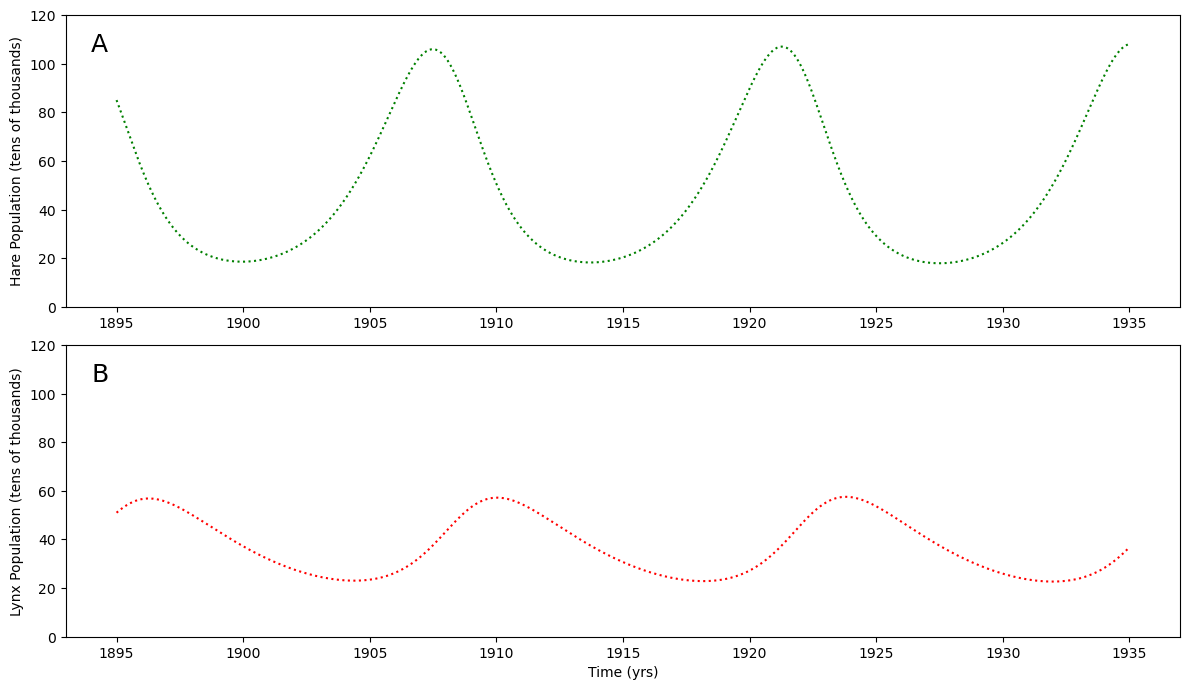

In [7]:
# Create a figure with two subplots stacked vertically (2 rows, 1 column)
# hare_ax is the axis for the hare population
# lynx_ax is the axis for the lynx population
fig, [hare_ax, lynx_ax] = plt.subplots(2, 1, figsize=(12, 8))

# ---- Plot hare population ----

# Solution Coding Exercise 6.4: Plot the hare population over time as a dotted green line
hare_ax.plot(time, H, ':', color='green')

# Set the y-axis limits for the hare population
hare_ax.set_ylim(0, 120)

# Label the y-axis
hare_ax.set_ylabel('Hare Population (tens of thousands)')

# Add a label 'A' to mark this subplot
hare_ax.text(1894, 105, 'A', fontsize=18)

# ---- Plot lynx population ----

# Solution Coding Exercise 6.4: Plot the lynx population over time as a dotted red line
lynx_ax.plot(time, L, ':', color='red')

# Set the y-axis limits for the lynx population
lynx_ax.set_ylim(0, 120)

# Label the x-axis and y-axis
lynx_ax.set_xlabel('Time (yrs)')
lynx_ax.set_ylabel('Lynx Population (tens of thousands)')

# Add a label 'B' to mark this subplot
lynx_ax.text(1894, 105, 'B', fontsize=18)

# Adjust spacing so labels and plots do not overlap
plt.tight_layout()

# Add extra space at the top of the figure
plt.subplots_adjust(top=0.85)

# Display the figure
plt.show()


### Coding Exercise 4.5: Plotting the Simulated Populations as one plot

In the plot: 
* plot the simulated Hare population, H, as a dotted ':' green line, as a function of time and add the label Hare Population.
* plot the simulated Lynx population, L, as a dotted ':' red line, as a function of time  and add the label Lynx Population. 

__Hint:__ use the `plt.plot(x,y,':',label='name')` function.

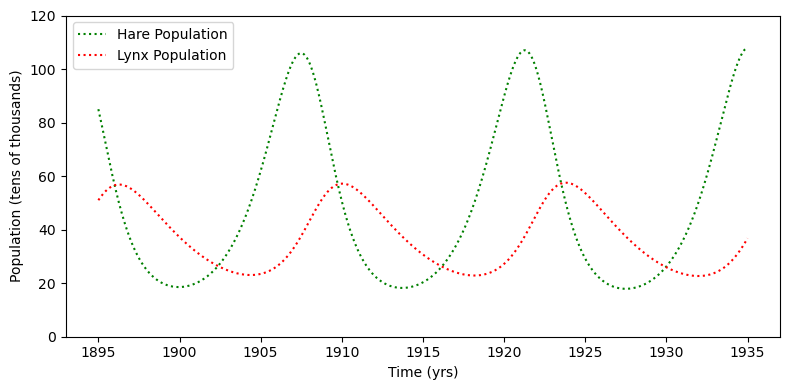

In [8]:
# Create a new figure with a specified width and height (in inches)
fig = plt.figure(figsize=(8, 4))


## Solution Coding Exercise 6.5: Plotting the Simulated Populations as one plot

# Plot the hare population as a dotted green line
plt.plot(time, H, ':', color='green', label='Hare Population')
# Plot the lynx population as a dotted red line
plt.plot(time, L, ':', color='red', label='Lynx Population')
### 

# Add a legend to identify each population
plt.legend()

# Set the limits of the y-axis
plt.ylim(0, 120)

# Label the x-axis and y-axis
plt.xlabel('Time (yrs)')
plt.ylabel('Population (tens of thousands)')

# Automatically adjust spacing so labels fit neatly
plt.tight_layout()

# Display the plot on the screen
plt.show()


### Reflective Exercise 4.5: Up and Down
Look at the plot below. For each of the four highlighted regions, describe what is happening to the hare and lynx populations populations.

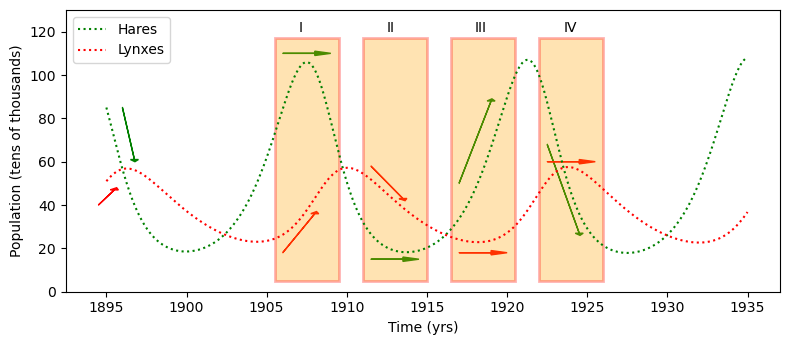

In [9]:
for i in range (0,N-1):
     
    H[i+1]=H[i]+timestep*(r_birth*H[i]-r_eat*H[i]*L[i])# 
    L[i+1]=L[i]+timestep*(-r_death*L[i]+r_food*H[i]*L[i])# 

fig = plt.figure(figsize=(8, 4))

## Plotting Figure
plt.plot(time,H,':',color='green',label='Hares')
plt.plot(time,L,':',color='red',label='Lynxes')
plt.legend()

plt.ylim(0,120)
plt.xlabel('Time (yrs)')
plt.ylabel('Population (tens of thousands)')
plt.arrow(1896, 85, 0.75, -24, head_width=0.5, head_length=1,color='green')
plt.arrow(1894.5, 40, 1, 7, head_width=0.5, head_length=1,color='red')

plt.text(1907,120,'I')
plt.arrow(1906, 110, 2, 0, head_width=2, head_length=1,color='green')
plt.arrow(1906, 18, 2, 18, head_width=0.5, head_length=1,color='red')
box = Rectangle((1905.5, 5), 4, 112, 
                linewidth=2, edgecolor='red', facecolor='orange', alpha=0.3)
plt.gca().add_patch(box)


plt.text(1912.5,120,'II')
plt.arrow(1911.5, 15, 2, 0, head_width=2, head_length=1,color='green')
plt.arrow(1911.5, 58, 2, -15, head_width=0.5, head_length=1,color='red')
box = Rectangle((1911, 5), 4, 112, 
                linewidth=2, edgecolor='red', facecolor='orange', alpha=0.3)
plt.gca().add_patch(box)

plt.text(1918,120,'III')
plt.arrow(1917, 50, 2, 38, head_width=0.5, head_length=1,color='green')
plt.arrow(1917, 18, 2, 0, head_width=2, head_length=1,color='red')
box = Rectangle((1916.5, 5), 4, 112, 
                linewidth=2, edgecolor='red', facecolor='orange', alpha=0.3)
plt.gca().add_patch(box)

plt.text(1923.5,120,'IV')
plt.arrow(1922.5, 68, 2, -41, head_width=0.5, head_length=1,color='green')
plt.arrow(1922.5, 60, 2, 0, head_width=2, head_length=1,color='red')
box = Rectangle((1922, 5), 4, 112, 
                linewidth=2, edgecolor='red', facecolor='orange', alpha=0.3)
plt.gca().add_patch(box)


plt.ylim(0,130)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


## Summary and Outro
- The Hare and Lynx populations have a similar up and down shape.

- The interaction of the Hares and Lynxes means the Hare population never gets to big or the Lynx population never gets to small.

__Next Lesson:__

Wolves